In [2]:
from pathlib import Path
import xml.etree.ElementTree as ET

import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image

In [3]:
PROJECT_ROOT = Path.cwd().parent

DATASET_ROOT = PROJECT_ROOT / "data" / "raw" / "groceries-5k" / "dataset"

image_path = DATASET_ROOT / "images" / "nuts" / "NUTS0042.png"
annotation_path = DATASET_ROOT / "annotations" / "nuts" / "NUTS0042.xml"

print(image_path)
print(annotation_path)

print("Image exists:", image_path.exists())
print("Annotation exists:", annotation_path.exists())

/home/sanket/retail-product-detection/data/raw/groceries-5k/dataset/images/nuts/NUTS0042.png
/home/sanket/retail-product-detection/data/raw/groceries-5k/dataset/annotations/nuts/NUTS0042.xml
Image exists: True
Annotation exists: True


In [4]:
tree = ET.parse(annotation_path)
root = tree.getroot()

print(root.tag)

annotation


In [6]:
filename = root.find("filename").text

width = int(root.find("size/width").text)
height = int(root.find("size/height").text)

print("Filename:", filename)
print("Width:", width)
print("Height:", height)

Filename: NUTS0042.png
Width: 224
Height: 224


In [7]:
objects = []

for obj in root.findall("object"):
    class_name = obj.find("name").text
    truncated = int(obj.find("truncated").text)
    difficult = int(obj.find("difficult").text)

    bbox = obj.find("bndbox")

    xmin = int(bbox.find("xmin").text)
    ymin = int(bbox.find("ymin").text)
    xmax = int(bbox.find("xmax").text)
    ymax = int(bbox.find("ymax").text)

    objects.append({
        "class": class_name,
        "xmin": xmin,
        "ymin": ymin,
        "xmax": xmax,
        "ymax": ymax,
        "truncated": truncated,
        "difficult": difficult
    })

objects

[{'class': 'nuts',
  'xmin': 108,
  'ymin': 67,
  'xmax': 209,
  'ymax': 174,
  'truncated': 0,
  'difficult': 0},
 {'class': 'nuts',
  'xmin': 1,
  'ymin': 55,
  'xmax': 109,
  'ymax': 172,
  'truncated': 1,
  'difficult': 0}]

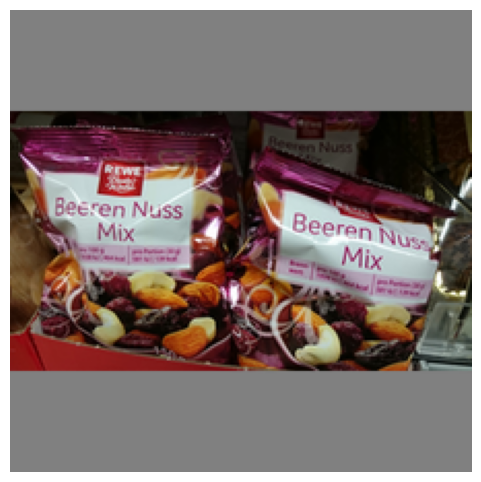

In [8]:
image = Image.open(image_path)

plt.figure(figsize=(6, 6))
plt.imshow(image)
plt.axis("off")
plt.show()

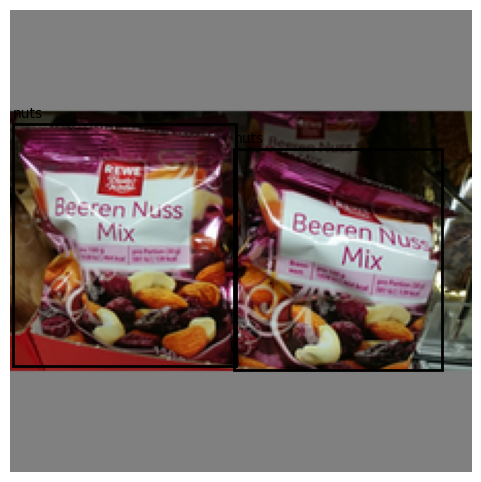

In [9]:
fig, ax = plt.subplots(figsize=(6, 6))

ax.imshow(image)

for obj in objects:
    xmin = obj["xmin"]
    ymin = obj["ymin"]
    xmax = obj["xmax"]
    ymax = obj["ymax"]

    box_width = xmax - xmin
    box_height = ymax - ymin

    rect = patches.Rectangle(
        (xmin, ymin),
        box_width,
        box_height,
        linewidth=2,
        fill=False
    )

    ax.add_patch(rect)

    ax.text(
        xmin,
        ymin - 3,
        obj["class"],
        fontsize=10
    )

ax.axis("off")
plt.show()

## Dataset-wide annotation analysis

Now that one image/annotation pair has been verified visually, inspect all annotations to understand:

- number of images and objects
- class distribution
- objects per image
- truncated objects
- invalid bounding boxes
- missing image/annotation pairs

In [11]:
from collections import Counter
import pandas as pd
import matplotlib.pyplot as plt

In [12]:
annotations_root = DATASET_ROOT / "annotations"
xml_files = list(annotations_root.rglob("*.xml"))

print("Number of XML files:", len(xml_files))

Number of XML files: 4947


In [13]:
records = []

for xml_path in xml_files:
    tree = ET.parse(xml_path)
    root = tree.getroot()

    filename = root.find("filename").text
    width = int(root.find("size/width").text)
    height = int(root.find("size/height").text)

    for obj in root.findall("object"):
        bbox = obj.find("bndbox")

        records.append({
            "filename": filename,
            "class": obj.find("name").text,
            "image_width": width,
            "image_height": height,
            "xmin": int(bbox.find("xmin").text),
            "ymin": int(bbox.find("ymin").text),
            "xmax": int(bbox.find("xmax").text),
            "ymax": int(bbox.find("ymax").text),
            "truncated": int(obj.find("truncated").text),
            "difficult": int(obj.find("difficult").text),
        })

df = pd.DataFrame(records)
df.head()

,filename,class,image_width,image_height,xmin,ymin,xmax,ymax,truncated,difficult
0,NUTS0042.png,nuts,224,224,108,67,209,174,0,0
1,NUTS0042.png,nuts,224,224,1,55,109,172,1,0
2,NUTS0019.png,nuts,224,224,104,50,209,174,0,0
3,NUTS0019.png,nuts,224,224,8,49,106,170,0,0
4,NUTS0106.png,nuts,224,224,57,92,169,170,0,0


In [14]:
print("Images:", df["filename"].nunique())
print("Objects:", len(df))
print("Classes:", df["class"].nunique())

Images: 4947
Objects: 11663
Classes: 25


In [15]:
objects_per_image = df.groupby("filename").size()
objects_per_image.describe()

count    4947.000000
mean        2.357590
std         1.405496
min         1.000000
25%         1.000000
50%         2.000000
75%         3.000000
max        14.000000
dtype: float64

In [16]:
df["truncated"].value_counts()

truncated
0    7187
1    4476
Name: count, dtype: int64

In [17]:
invalid_boxes = df[
    (df["xmin"] < 0) |
    (df["ymin"] < 0) |
    (df["xmax"] > df["image_width"]) |
    (df["ymax"] > df["image_height"]) |
    (df["xmax"] <= df["xmin"]) |
    (df["ymax"] <= df["ymin"])
]

print("Invalid boxes:", len(invalid_boxes))

Invalid boxes: 1


In [18]:
invalid_boxes

,filename,class,image_width,image_height,xmin,ymin,xmax,ymax,truncated,difficult
10319,FISH0041.png,fish,224,224,87,187,87,188,0,0


In [19]:
df["difficult"].value_counts()

difficult
0    11663
Name: count, dtype: int64

In [20]:
df[["image_width", "image_height"]].drop_duplicates()

,image_width,image_height
0,224,224


In [21]:
class_counts = df["class"].value_counts().sort_values(ascending=False)

class_counts

class
juice           848
jam             834
coffee          763
water           735
spices          663
chocolate       649
candy           624
tea             607
soda            532
cereal          472
vinegar         420
tomato_sauce    393
pasta           392
chips           384
milk            384
honey           363
oil             359
fish            337
corn            301
nuts            288
sugar           284
beans           282
cake            280
rice            275
flour           194
Name: count, dtype: int64

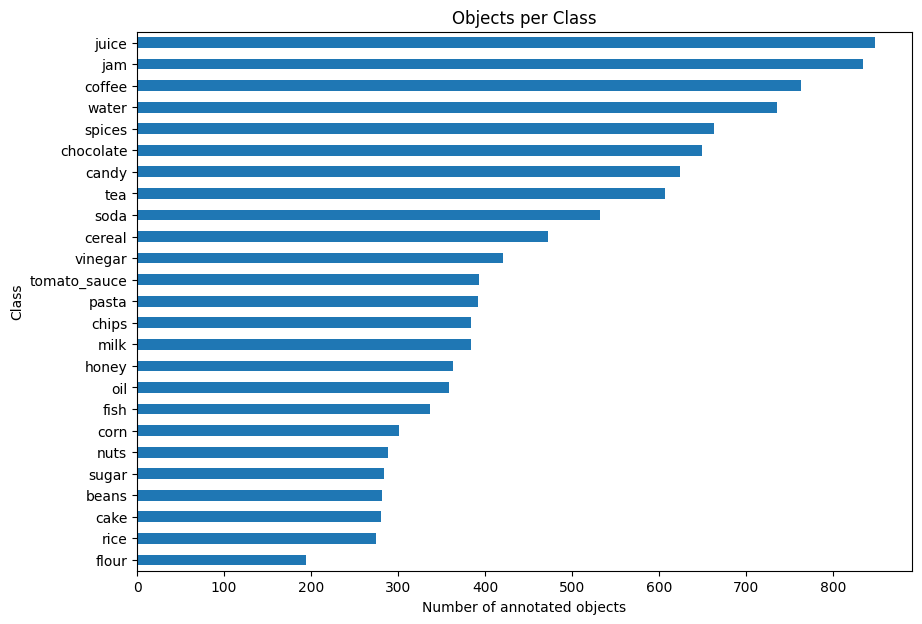

In [22]:
plt.figure(figsize=(10, 7))

class_counts.sort_values().plot(kind="barh")

plt.xlabel("Number of annotated objects")
plt.ylabel("Class")
plt.title("Objects per Class")

plt.show()

In [23]:
print("Largest class:", class_counts.index[0], class_counts.iloc[0])
print("Smallest class:", class_counts.index[-1], class_counts.iloc[-1])
print("Largest / smallest ratio:", class_counts.iloc[0] / class_counts.iloc[-1])

Largest class: juice 848
Smallest class: flour 194
Largest / smallest ratio: 4.371134020618556


In [24]:
class_counts.describe()

count     25.00000
mean     466.52000
std      193.59152
min      194.00000
25%      301.00000
50%      392.00000
75%      624.00000
max      848.00000
Name: count, dtype: float64

In [25]:
image_df = (
    df.groupby("filename")
    .agg(
        class_name=("class", "first"),
        num_objects=("class", "size")
    )
    .reset_index()
)

image_df.head()

,filename,class_name,num_objects
0,BEANS0000.png,beans,1
1,BEANS0001.png,beans,2
2,BEANS0002.png,beans,1
3,BEANS0003.png,beans,5
4,BEANS0004.png,beans,1


In [26]:
print(len(image_df))
print(image_df["class_name"].nunique())

4947
25


In [28]:
from sklearn.model_selection import train_test_split

In [29]:
train_df, temp_df = train_test_split(
    image_df,
    test_size=0.20,
    random_state=42,
    stratify=image_df["class_name"]
)

In [30]:
val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    random_state=42,
    stratify=temp_df["class_name"]
)

In [31]:
print("Train:", len(train_df))
print("Validation:", len(val_df))
print("Test:", len(test_df))

Train: 3957
Validation: 495
Test: 495


In [32]:
print("Train classes:", train_df["class_name"].nunique())
print("Val classes:", val_df["class_name"].nunique())
print("Test classes:", test_df["class_name"].nunique())

Train classes: 25
Val classes: 25
Test classes: 25


In [33]:
classes_per_image = df.groupby("filename")["class"].nunique()

print(classes_per_image.value_counts())

class
1    4947
Name: count, dtype: int64


In [34]:
print("Train classes:", train_df["class_name"].nunique())
print("Val classes:", val_df["class_name"].nunique())
print("Test classes:", test_df["class_name"].nunique())

Train classes: 25
Val classes: 25
Test classes: 25


In [35]:
split_distribution = pd.concat([
    train_df["class_name"].value_counts().rename("train"),
    val_df["class_name"].value_counts().rename("val"),
    test_df["class_name"].value_counts().rename("test")
], axis=1).fillna(0).astype(int)

split_distribution

,train,val,test
class_name,,,
candy,297,38,37
chocolate,245,31,31
juice,241,30,31
coffee,238,30,30
tea,226,29,28
cereal,222,28,28
water,210,26,26
jam,193,24,24
spices,166,21,20


In [36]:
classes_per_image = df.groupby("filename")["class"].nunique()

print(classes_per_image.value_counts())

class
1    4947
Name: count, dtype: int64


In [37]:
SPLIT_DIR = PROJECT_ROOT / "configs" / "splits"
SPLIT_DIR.mkdir(parents=True, exist_ok=True)

train_df.to_csv(SPLIT_DIR / "train.csv", index=False)
val_df.to_csv(SPLIT_DIR / "val.csv", index=False)
test_df.to_csv(SPLIT_DIR / "test.csv", index=False)

In [38]:
print(len(pd.read_csv(SPLIT_DIR / "train.csv")))
print(len(pd.read_csv(SPLIT_DIR / "val.csv")))
print(len(pd.read_csv(SPLIT_DIR / "test.csv")))

3957
495
495


In [39]:
classes_per_image = df.groupby("filename")["class"].nunique()
print(classes_per_image.value_counts())

class
1    4947
Name: count, dtype: int64


In [40]:
classes = sorted(df["class"].unique())

class_to_id = {
    class_name: idx
    for idx, class_name in enumerate(classes)
}

class_to_id

{'beans': 0,
 'cake': 1,
 'candy': 2,
 'cereal': 3,
 'chips': 4,
 'chocolate': 5,
 'coffee': 6,
 'corn': 7,
 'fish': 8,
 'flour': 9,
 'honey': 10,
 'jam': 11,
 'juice': 12,
 'milk': 13,
 'nuts': 14,
 'oil': 15,
 'pasta': 16,
 'rice': 17,
 'soda': 18,
 'spices': 19,
 'sugar': 20,
 'tea': 21,
 'tomato_sauce': 22,
 'vinegar': 23,
 'water': 24}

In [41]:
import json

with open(PROJECT_ROOT / "configs" / "class_mapping.json", "w") as f:
    json.dump(class_to_id, f, indent=2)

In [42]:
def voc_to_yolo(xmin, ymin, xmax, ymax, image_width, image_height):
    box_width = xmax - xmin
    box_height = ymax - ymin

    x_center = xmin + box_width / 2
    y_center = ymin + box_height / 2

    x_center /= image_width
    y_center /= image_height
    box_width /= image_width
    box_height /= image_height

    return x_center, y_center, box_width, box_height

In [43]:
voc_to_yolo(
    xmin=108,
    ymin=67,
    xmax=209,
    ymax=174,
    image_width=224,
    image_height=224
)

(0.7075892857142857,
 0.5379464285714286,
 0.45089285714285715,
 0.47767857142857145)

In [44]:
voc_to_yolo(
    xmin=1,
    ymin=55,
    xmax=109,
    ymax=172,
    image_width=224,
    image_height=224
)

(0.24553571428571427,
 0.5066964285714286,
 0.48214285714285715,
 0.5223214285714286)

In [45]:
import shutil

In [46]:
from pathlib import Path
import xml.etree.ElementTree as ET
import pandas as pd

In [47]:
YOLO_ROOT = PROJECT_ROOT / "data" / "processed" / "yolo"

for split in ["train", "val", "test"]:
    (YOLO_ROOT / "images" / split).mkdir(parents=True, exist_ok=True)
    (YOLO_ROOT / "labels" / split).mkdir(parents=True, exist_ok=True)

In [48]:
def convert_split(split_df, split_name):
    skipped_boxes = 0
    written_boxes = 0
    images_with_no_valid_boxes = []

    for _, row in split_df.iterrows():
        filename = row["filename"]
        class_folder = row["class_name"]

        image_path = (
            DATASET_ROOT
            / "images"
            / class_folder
            / filename
        )

        xml_path = (
            DATASET_ROOT
            / "annotations"
            / class_folder
            / Path(filename).with_suffix(".xml")
        )

        if not image_path.exists():
            raise FileNotFoundError(f"Missing image: {image_path}")

        if not xml_path.exists():
            raise FileNotFoundError(f"Missing annotation: {xml_path}")

        tree = ET.parse(xml_path)
        root = tree.getroot()

        image_width = int(root.find("size/width").text)
        image_height = int(root.find("size/height").text)

        yolo_lines = []

        for obj in root.findall("object"):
            class_name = obj.find("name").text
            class_id = class_to_id[class_name]

            bbox = obj.find("bndbox")

            xmin = int(bbox.find("xmin").text)
            ymin = int(bbox.find("ymin").text)
            xmax = int(bbox.find("xmax").text)
            ymax = int(bbox.find("ymax").text)

            # Skip malformed bounding boxes
            if (
                xmin < 0
                or ymin < 0
                or xmax > image_width
                or ymax > image_height
                or xmax <= xmin
                or ymax <= ymin
            ):
                skipped_boxes += 1
                continue

            x_center, y_center, box_width, box_height = voc_to_yolo(
                xmin,
                ymin,
                xmax,
                ymax,
                image_width,
                image_height,
            )

            yolo_lines.append(
                f"{class_id} "
                f"{x_center:.6f} "
                f"{y_center:.6f} "
                f"{box_width:.6f} "
                f"{box_height:.6f}"
            )

            written_boxes += 1

        if len(yolo_lines) == 0:
            images_with_no_valid_boxes.append(filename)

        destination_image = YOLO_ROOT / "images" / split_name / filename

        destination_label = (
            YOLO_ROOT
            / "labels"
            / split_name
            / Path(filename).with_suffix(".txt")
        )

        shutil.copy2(image_path, destination_image)

        destination_label.write_text(
            "\n".join(yolo_lines)
        )

    return {
        "images": len(split_df),
        "boxes_written": written_boxes,
        "boxes_skipped": skipped_boxes,
        "images_with_no_valid_boxes": images_with_no_valid_boxes,
    }

In [49]:
train_stats = convert_split(train_df, "train")
train_stats

{'images': 3957,
 'boxes_written': 9359,
 'boxes_skipped': 1,
 'images_with_no_valid_boxes': []}

In [50]:
train_images = list((YOLO_ROOT / "images" / "train").glob("*"))
train_labels = list((YOLO_ROOT / "labels" / "train").glob("*.txt"))

print("Train images:", len(train_images))
print("Train labels:", len(train_labels))

Train images: 3957
Train labels: 3957


In [51]:
label_path = YOLO_ROOT / "labels" / "train" / "NUTS0042.txt"

if label_path.exists():
    print(label_path.read_text())
else:
    print("NUTS0042 is not in the train split.")

14 0.707589 0.537946 0.450893 0.477679
14 0.245536 0.506696 0.482143 0.522321


In [52]:
val_stats = convert_split(val_df, "val")
test_stats = convert_split(test_df, "test")

print("Train:", train_stats)
print("Validation:", val_stats)
print("Test:", test_stats)

Train: {'images': 3957, 'boxes_written': 9359, 'boxes_skipped': 1, 'images_with_no_valid_boxes': []}
Validation: {'images': 495, 'boxes_written': 1130, 'boxes_skipped': 0, 'images_with_no_valid_boxes': []}
Test: {'images': 495, 'boxes_written': 1173, 'boxes_skipped': 0, 'images_with_no_valid_boxes': []}


In [53]:
for split in ["train", "val", "test"]:
    num_images = len(list((YOLO_ROOT / "images" / split).glob("*")))
    num_labels = len(list((YOLO_ROOT / "labels" / split).glob("*.txt")))

    print(
        split,
        "images =", num_images,
        "labels =", num_labels
    )

train images = 3957 labels = 3957
val images = 495 labels = 495
test images = 495 labels = 495


In [54]:
def yolo_to_xyxy(x_center, y_center, box_width, box_height,
                 image_width, image_height):

    x_center *= image_width
    y_center *= image_height
    box_width *= image_width
    box_height *= image_height

    xmin = x_center - box_width / 2
    ymin = y_center - box_height / 2
    xmax = x_center + box_width / 2
    ymax = y_center + box_height / 2

    return xmin, ymin, xmax, ymax

In [55]:
id_to_class = {v: k for k, v in class_to_id.items()}

In [56]:
def visualize_yolo_sample(split, filename):
    image_path = YOLO_ROOT / "images" / split / filename
    label_path = YOLO_ROOT / "labels" / split / Path(filename).with_suffix(".txt")

    image = Image.open(image_path)

    width, height = image.size

    fig, ax = plt.subplots(figsize=(6, 6))
    ax.imshow(image)

    with open(label_path) as f:
        lines = f.readlines()

    for line in lines:
        class_id, xc, yc, bw, bh = line.strip().split()

        class_id = int(class_id)

        xc = float(xc)
        yc = float(yc)
        bw = float(bw)
        bh = float(bh)

        xmin, ymin, xmax, ymax = yolo_to_xyxy(
            xc, yc, bw, bh,
            width, height
        )

        rect = patches.Rectangle(
            (xmin, ymin),
            xmax - xmin,
            ymax - ymin,
            linewidth=2,
            fill=False
        )

        ax.add_patch(rect)

        ax.text(
            xmin,
            ymin - 3,
            id_to_class[class_id],
            fontsize=10
        )

    ax.axis("off")
    plt.show()

In [57]:
sample_filename = train_df.iloc[0]["filename"]
sample_filename

'NUTS0062.png'

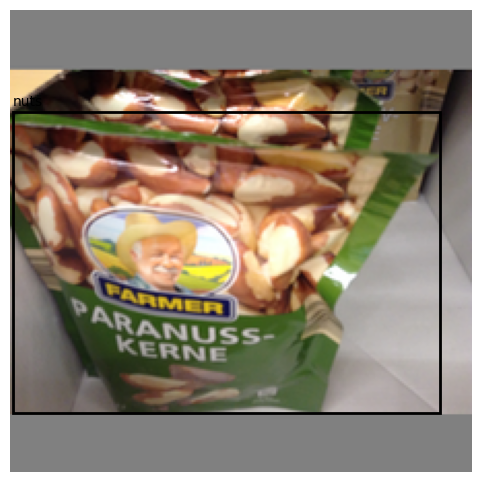

In [58]:
visualize_yolo_sample(
    "train",
    sample_filename
)

SPICES0147.png


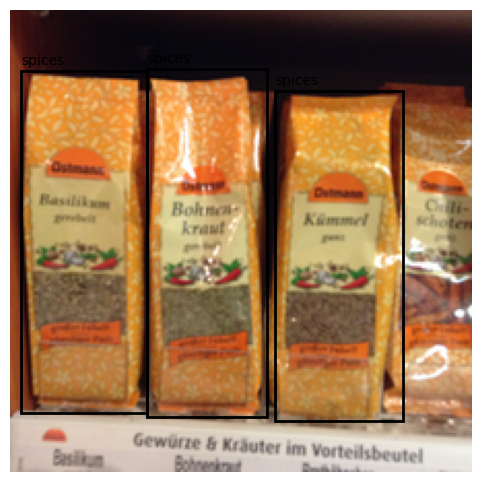

CEREAL0132.png


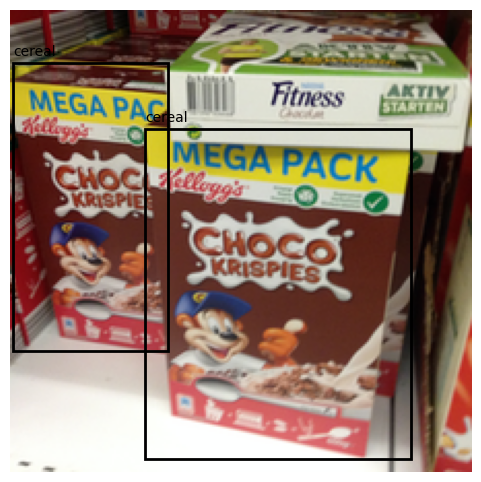

CEREAL0128.png


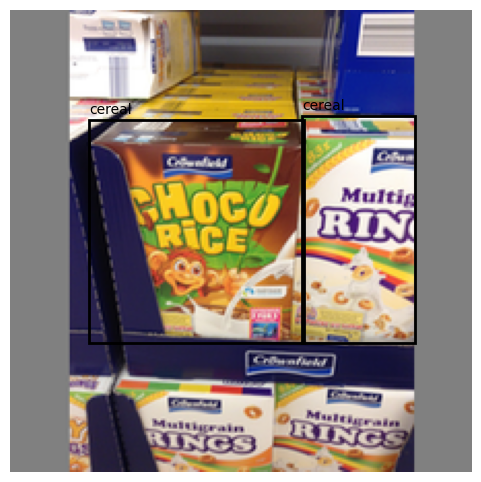

SUGAR0115.png


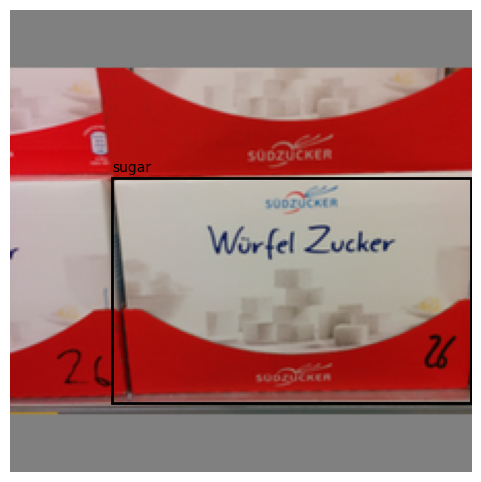

COFFEE0165.png


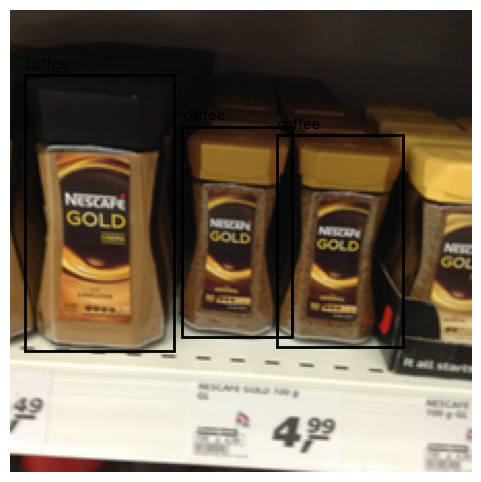

In [59]:
for filename in train_df.sample(5, random_state=42)["filename"]:
    print(filename)
    visualize_yolo_sample("train", filename)

In [60]:
class_to_id

{'beans': 0,
 'cake': 1,
 'candy': 2,
 'cereal': 3,
 'chips': 4,
 'chocolate': 5,
 'coffee': 6,
 'corn': 7,
 'fish': 8,
 'flour': 9,
 'honey': 10,
 'jam': 11,
 'juice': 12,
 'milk': 13,
 'nuts': 14,
 'oil': 15,
 'pasta': 16,
 'rice': 17,
 'soda': 18,
 'spices': 19,
 'sugar': 20,
 'tea': 21,
 'tomato_sauce': 22,
 'vinegar': 23,
 'water': 24}

In [61]:
import yaml

dataset_yaml = {
    "path": str(YOLO_ROOT.resolve()),
    "train": "images/train",
    "val": "images/val",
    "test": "images/test",
    "names": {
        class_id: class_name
        for class_name, class_id in class_to_id.items()
    }
}

yaml_path = PROJECT_ROOT / "configs" / "groceries.yaml"

with open(yaml_path, "w") as f:
    yaml.safe_dump(dataset_yaml, f, sort_keys=False)

print(yaml_path)

/home/sanket/retail-product-detection/configs/groceries.yaml


In [62]:
print(yaml_path.read_text())

path: /home/sanket/retail-product-detection/data/processed/yolo
train: images/train
val: images/val
test: images/test
names:
  0: beans
  1: cake
  2: candy
  3: cereal
  4: chips
  5: chocolate
  6: coffee
  7: corn
  8: fish
  9: flour
  10: honey
  11: jam
  12: juice
  13: milk
  14: nuts
  15: oil
  16: pasta
  17: rice
  18: soda
  19: spices
  20: sugar
  21: tea
  22: tomato_sauce
  23: vinegar
  24: water



In [63]:
print(yaml_path.read_text())

path: /home/sanket/retail-product-detection/data/processed/yolo
train: images/train
val: images/val
test: images/test
names:
  0: beans
  1: cake
  2: candy
  3: cereal
  4: chips
  5: chocolate
  6: coffee
  7: corn
  8: fish
  9: flour
  10: honey
  11: jam
  12: juice
  13: milk
  14: nuts
  15: oil
  16: pasta
  17: rice
  18: soda
  19: spices
  20: sugar
  21: tea
  22: tomato_sauce
  23: vinegar
  24: water



In [64]:
from ultralytics.data.utils import check_det_dataset

dataset_info = check_det_dataset(str(yaml_path))
dataset_info

{'path': PosixPath('/home/sanket/retail-product-detection/data/processed/yolo'),
 'train': '/home/sanket/retail-product-detection/data/processed/yolo/images/train',
 'val': '/home/sanket/retail-product-detection/data/processed/yolo/images/val',
 'test': '/home/sanket/retail-product-detection/data/processed/yolo/images/test',
 'names': {0: 'beans',
  1: 'cake',
  2: 'candy',
  3: 'cereal',
  4: 'chips',
  5: 'chocolate',
  6: 'coffee',
  7: 'corn',
  8: 'fish',
  9: 'flour',
  10: 'honey',
  11: 'jam',
  12: 'juice',
  13: 'milk',
  14: 'nuts',
  15: 'oil',
  16: 'pasta',
  17: 'rice',
  18: 'soda',
  19: 'spices',
  20: 'sugar',
  21: 'tea',
  22: 'tomato_sauce',
  23: 'vinegar',
  24: 'water'},
 'yaml_file': '/home/sanket/retail-product-detection/configs/groceries.yaml',
 'nc': 25,
 'channels': 3}